# Unsupervised Learning — Complete Guide
### Machine-Learning Algorithm Selection Framework | Notebook 2 of 6

> **Companion notebook to:** *A Reproducible Framework for Machine Learning Algorithm Selection* (Alsammani, Delaware State University)

Unsupervised learning discovers hidden structure in **unlabeled** data: clusters, latent dimensions,
densities, and co-occurrence patterns.

| Algorithm family | Goal |
|---|---|
| Clustering | Partition data into meaningful groups |
| Dimensionality reduction | Compress features while preserving structure |
| Density estimation | Model the underlying data distribution |
| Anomaly detection | Identify unusual observations |
| Association rules | Find frequent item co-occurrences |

**Evaluation challenge:** Without ground-truth labels, quality must be assessed with internal metrics
(silhouette score, Davies-Bouldin index) or, when labels are available for comparison,
external metrics (Adjusted Rand Index, Normalized Mutual Information).


---
## Setup — Imports and Global Configuration

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

from sklearn.datasets import load_iris, load_breast_cancer, load_wine, make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score,
    davies_bouldin_score, calinski_harabasz_score
)
from itertools import combinations

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("umap-learn not installed. Install with: pip install umap-learn")
    print("UMAP section will be skipped.")

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
SEED = 42; np.random.seed(SEED)
print("Setup complete.")


umap-learn not installed. Install with: pip install umap-learn
UMAP section will be skipped.
Setup complete.


---
# 1. K-Means Clustering
## Mathematical Foundation

K-Means minimizes within-cluster sum of squares (WCSS):

$$\underset{\{C_j\}, \{\boldsymbol{\mu}_j\}}{\min}\; \sum_{j=1}^k \sum_{\mathbf{x}_i \in C_j} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2$$

**Lloyd's algorithm:** Alternates between assignment and centroid update steps, converging to a
local minimum. Complexity: $O(nkdI)$ for $I$ iterations.

**k-means++** initialization selects centroids with probability proportional to squared distance
from existing centroids, providing an $O(\log k)$ approximation guarantee.

**Choosing k:**

| Method | Approach |
|---|---|
| Elbow method | Plot WCSS vs $k$; look for the "elbow" point |
| Silhouette analysis | Maximize average $s(i) = (b(i)-a(i))/\max(a(i),b(i))$ |
| Gap statistic | Compare WCSS to a null reference distribution |

**Relation to GMM:** k-Means is the degenerate limit of a GMM when all $\boldsymbol{\Sigma}_j = \sigma^2 I$
and $\sigma \to 0$ — it performs hard assignments instead of soft.

## When to Use / Avoid
| | Condition |
|---|---|
| ✅ **Use** | Clusters are approximately spherical and equal-sized; $k$ is estimable |
| ❌ **Avoid** | Irregular cluster shapes; varying density; significant outliers |

**Primary domains:** Customer segmentation, image compression, vector quantization.


  File "C:\Users\abdal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\abdal\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abdal\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abdal\anaconda3\Lib\subprocess.

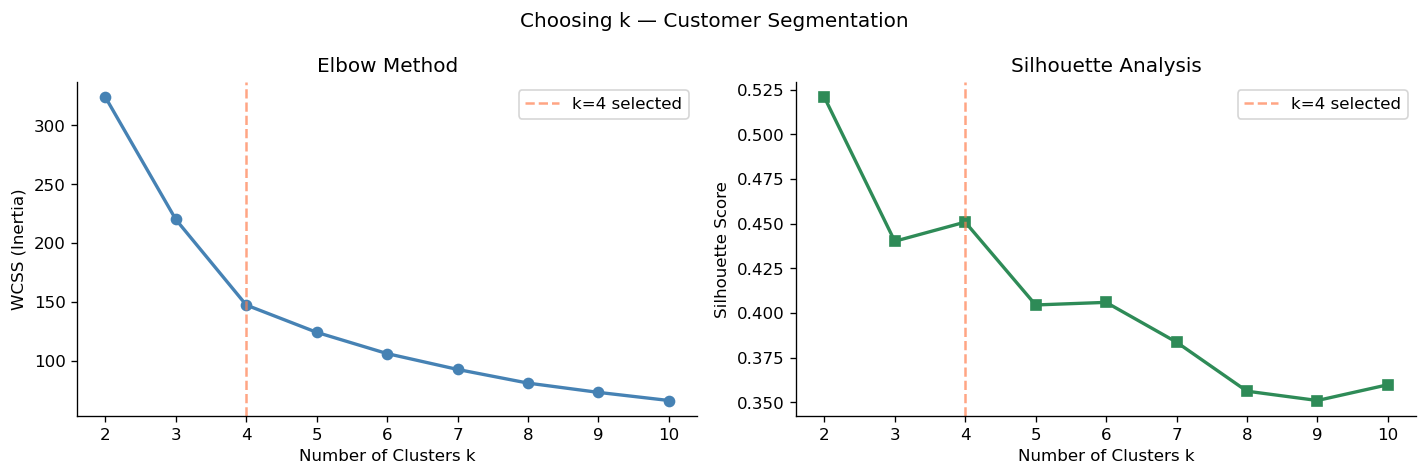

In [2]:
# ── Synthetic customer dataset ────────────────────────────────
np.random.seed(SEED)
n = 400
income    = np.concatenate([np.random.normal(35, 8, 100), np.random.normal(60, 10, 100),
                             np.random.normal(85, 8, 100), np.random.normal(50, 12, 100)])
spending  = np.concatenate([np.random.normal(70, 10, 100), np.random.normal(80, 8, 100),
                             np.random.normal(30, 10, 100), np.random.normal(50, 15, 100)])
df_cust = pd.DataFrame({"Annual Income (k$)": income, "Spending Score": spending})
X_cust = StandardScaler().fit_transform(df_cust.values)

# ── Elbow + Silhouette ─────────────────────────────────────────
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=SEED)
    labels = km.fit_predict(X_cust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cust, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, "o-", color="steelblue", lw=2)
axes[0].set_xlabel("Number of Clusters k"); axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method")
axes[1].plot(K_range, sil_scores, "s-", color="seagreen", lw=2)
axes[1].set_xlabel("Number of Clusters k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")
for ax in axes:
    ax.axvline(4, color="coral", linestyle="--", alpha=0.7, label="k=4 selected")
    ax.legend()
plt.suptitle("Choosing k — Customer Segmentation", fontsize=12); plt.tight_layout(); plt.show()


── Cluster Sizes ──
0     67
1    120
2     99
3    114

Inertia: 147.20  |  Silhouette: 0.4509
Davies-Bouldin: 0.7562  (lower is better)


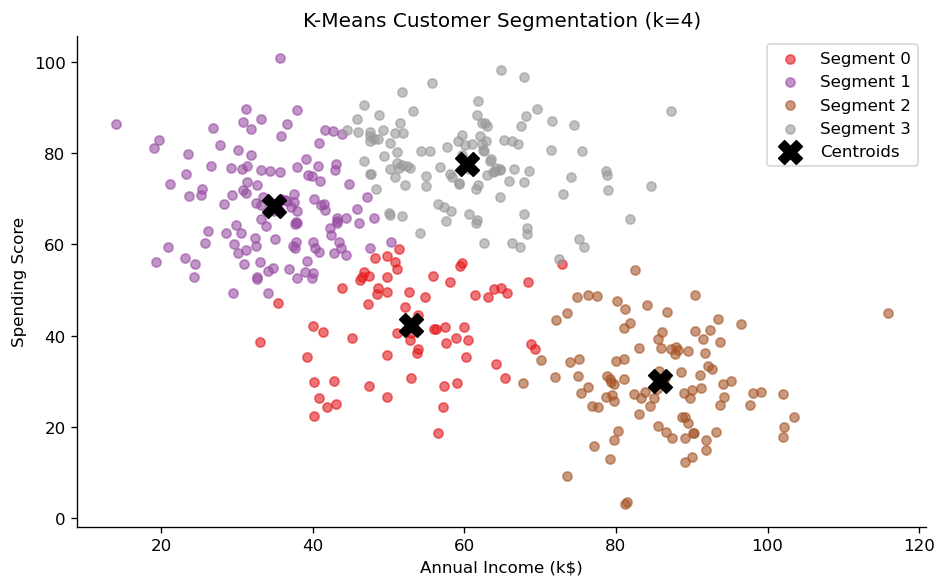

In [3]:
# ── Fit optimal k=4 ────────────────────────────────────────────
km4 = KMeans(n_clusters=4, init="k-means++", n_init=20, random_state=SEED)
labels4 = km4.fit_predict(X_cust)
centers4 = km4.cluster_centers_

print("── Cluster Sizes ──")
print(pd.Series(labels4).value_counts().sort_index().to_string())
print(f"\nInertia: {km4.inertia_:.2f}  |  Silhouette: {silhouette_score(X_cust, labels4):.4f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_cust, labels4):.4f}  (lower is better)")

fig, ax = plt.subplots(figsize=(8, 5))
palette = plt.cm.Set1(np.linspace(0,1,4))
for c in range(4):
    mask = labels4 == c
    orig = df_cust.values[mask]
    ax.scatter(orig[:,0], orig[:,1], label=f"Segment {c}", alpha=0.6, s=30, color=palette[c])
centers_orig = StandardScaler().fit(df_cust.values).inverse_transform(centers4)
ax.scatter(centers_orig[:,0], centers_orig[:,1], c="black", marker="X", s=200,
           zorder=5, label="Centroids")
ax.set_xlabel("Annual Income (k$)"); ax.set_ylabel("Spending Score")
ax.set_title("K-Means Customer Segmentation (k=4)"); ax.legend()
plt.tight_layout(); plt.show()


### Interpretation

- **4 segments** emerge: high-income/low-spending (conservatives), high-income/high-spending
  (premium customers), low-income/high-spending (aspirational), and mid-tier.
- The elbow at $k=4$ coincides with the silhouette peak, confirming the choice.
- **Centroid coordinates** provide actionable segment profiles for marketing strategy.


---
# 2. Hierarchical Clustering
## Mathematical Foundation

Agglomerative clustering builds a **dendrogram** by iteratively merging the two closest clusters.

**Linkage criteria** define inter-cluster distance:

| Linkage | Distance | Tendency |
|---|---|---|
| Single | $\min_{a\in A, b\in B} d(a,b)$ | Elongated chains (chaining effect) |
| Complete | $\max_{a\in A, b\in B} d(a,b)$ | Compact, equal-diameter clusters |
| Average | $\frac{1}{|A||B|}\sum d(a,b)$ | Compromise between single and complete |
| Ward | Minimizes within-cluster WCSS increase | Equal-sized, spherical clusters |

**Complexity:** $O(n^2)$ for single/complete; $O(n^2 \log n)$ for Ward.

The dendrogram supports any flat partition by cutting at any height — no rerunning required.

## When to Use / Avoid
| | Condition |
|---|---|
| ✅ **Use** | Hierarchical structure expected; $n \leq 10^4$; dendrogram visualization valuable |
| ❌ **Avoid** | $n > 10^4$ (quadratic complexity); flat clustering is sufficient |


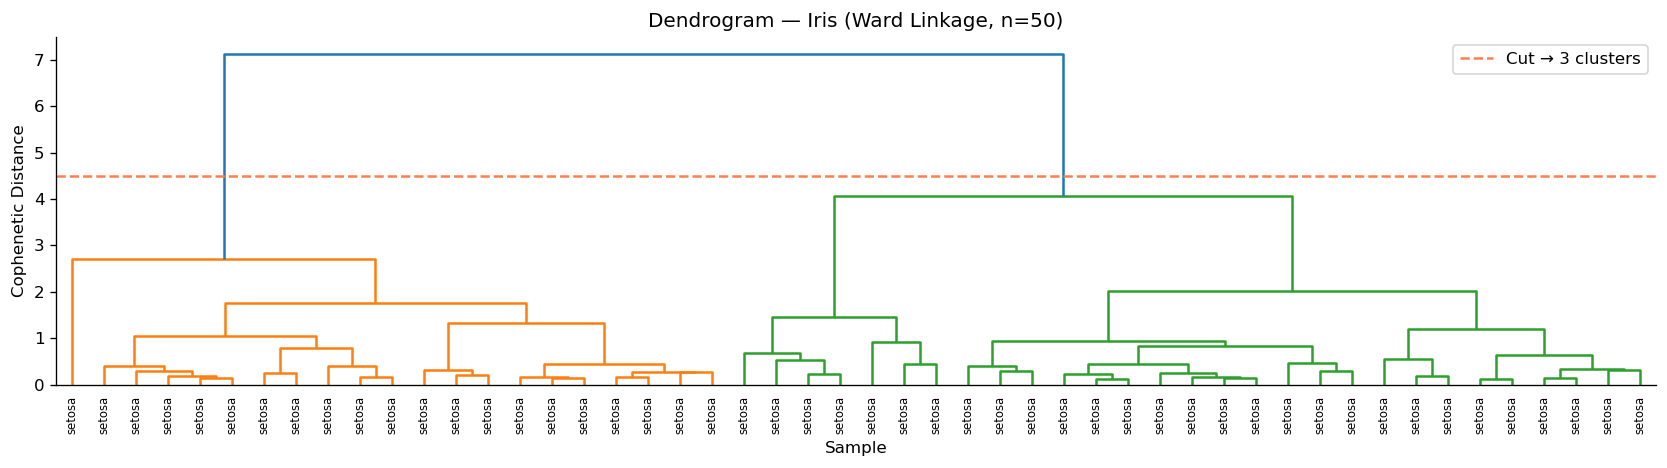

In [4]:
# ── Dataset: Iris species recovery ───────────────────────────
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

# ── Dendrogram (Ward, first 50 samples for clarity) ───────────
Z = linkage(X_iris[:50], method="ward")
fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(Z, ax=ax, color_threshold=4.5, leaf_font_size=7,
           labels=[iris.target_names[y] for y in y_iris[:50]])
ax.set_title("Dendrogram — Iris (Ward Linkage, n=50)")
ax.set_xlabel("Sample"); ax.set_ylabel("Cophenetic Distance")
ax.axhline(4.5, color="coral", linestyle="--", lw=1.5, label="Cut → 3 clusters")
ax.legend(); plt.tight_layout(); plt.show()


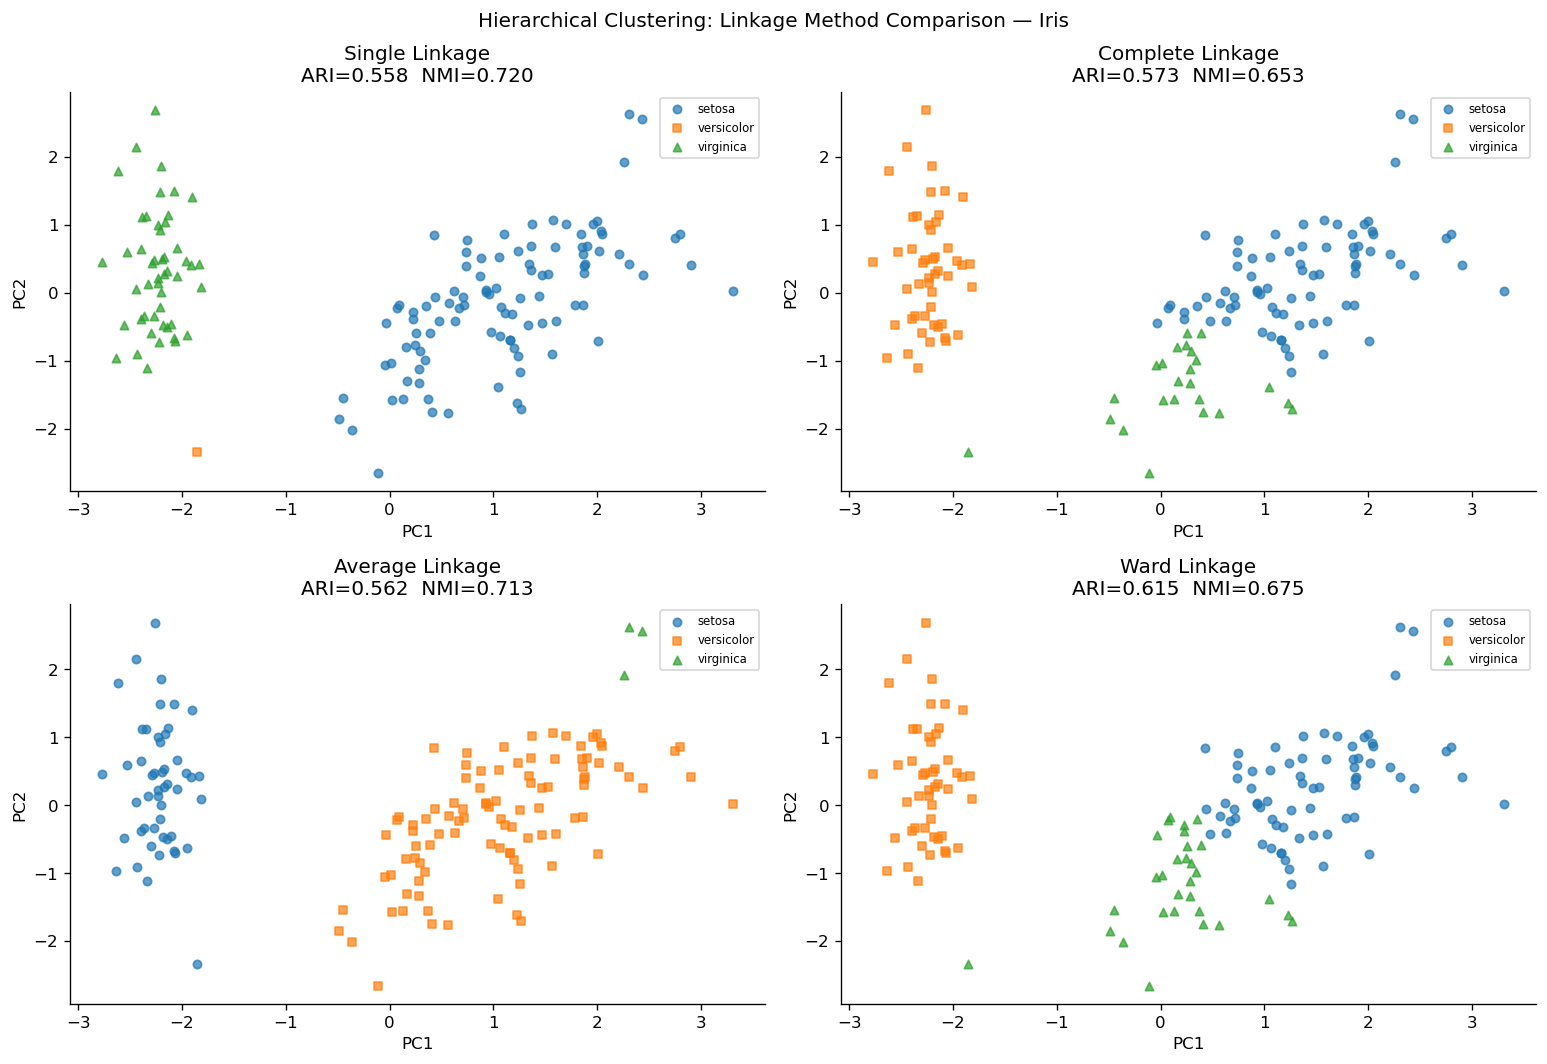

In [5]:
# ── Compare 4 linkage methods ─────────────────────────────────
linkage_methods = ["single", "complete", "average", "ward"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_iris)

for ax, method in zip(axes.flat, linkage_methods):
    hc = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = hc.fit_predict(X_iris)
    ari = adjusted_rand_score(y_iris, labels)
    nmi = normalized_mutual_info_score(y_iris, labels)
    for c, name, marker in zip(range(3), iris.target_names, ["o","s","^"]):
        mask = labels == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=name, alpha=0.7, s=25, marker=marker)
    ax.set_title(f"{method.capitalize()} Linkage\nARI={ari:.3f}  NMI={nmi:.3f}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=7)

plt.suptitle("Hierarchical Clustering: Linkage Method Comparison — Iris", fontsize=12)
plt.tight_layout(); plt.show()


### Interpretation

- **Ward linkage** produces the best ARI because it minimizes WCSS at each merge step,
  forming compact clusters that closely match the true Iris species.
- **Single linkage** suffers from chaining: one long chain instead of three groups.
- The dendrogram cut is determined by the longest gap in merge distances — the horizontal
  distance between successive merges indicates how natural a partition is.


---
# 3. DBSCAN — Density-Based Spatial Clustering
## Mathematical Foundation

DBSCAN classifies points as:
- **Core point:** has $\geq$ MinPts points within radius $\varepsilon$
- **Border point:** within $\varepsilon$ of a core point but has fewer than MinPts neighbors
- **Noise point:** neither core nor border

Clusters are **maximal sets of density-connected points** — transitive closure of direct
density-reachability from core points.

**Complexity:** $O(nd \log n)$ with spatial indexing (KD-tree); $O(n^2 d)$ brute-force.

**Choosing parameters:**
- $\varepsilon$: use the k-distance plot (elbow in sorted distances to $k$-th nearest neighbor)
- MinPts: rule of thumb $\geq 2d$; larger values for noisy data

HDBSCAN extends DBSCAN by building a hierarchy of density levels, handling clusters of varying density.

## When to Use / Avoid
| | Condition |
|---|---|
| ✅ **Use** | Arbitrary cluster shapes; outlier identification needed; low-dimensional data |
| ❌ **Avoid** | Varying-density clusters (use HDBSCAN); high $d$ ($>20$) |

**Primary domains:** Spatial data mining, anomaly detection, image segmentation.


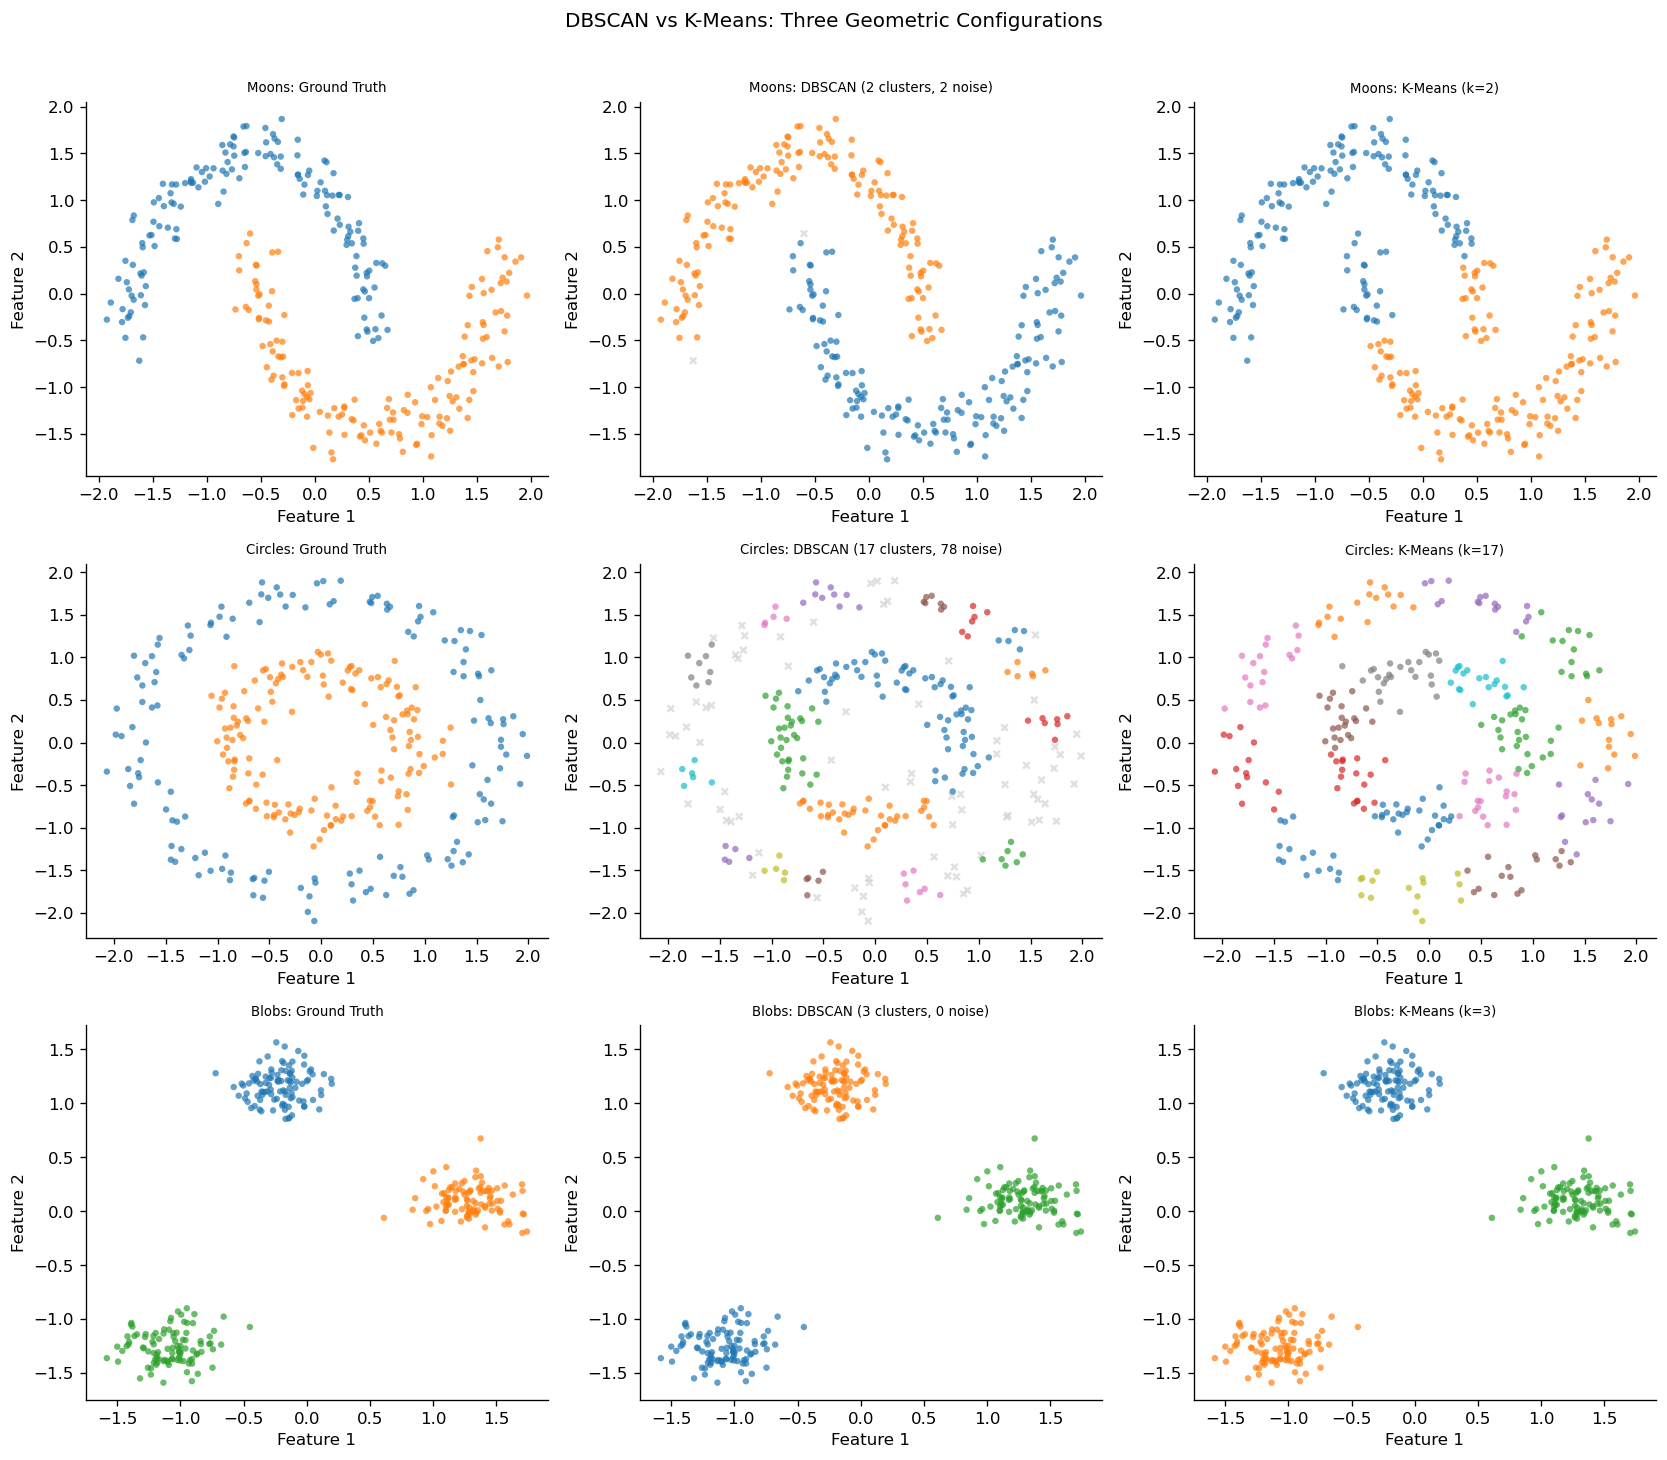

In [6]:
# ── Challenging synthetic datasets ────────────────────────────
X_moons,   y_moons   = make_moons(n_samples=300, noise=0.08, random_state=SEED)
X_circles, y_circles = make_circles(n_samples=300, noise=0.08, factor=0.5, random_state=SEED)
X_blobs,   y_blobs   = make_blobs(n_samples=300, centers=3, random_state=SEED)

datasets = [
    ("Moons",   X_moons,   y_moons,   {"eps": 0.25, "min_samples": 5}),
    ("Circles", X_circles, y_circles, {"eps": 0.20, "min_samples": 5}),
    ("Blobs",   X_blobs,   y_blobs,   {"eps": 1.0,  "min_samples": 5}),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
for row, (name, X_d, y_d, params) in enumerate(datasets):
    X_s = StandardScaler().fit_transform(X_d)
    # DBSCAN
    db = DBSCAN(**params)
    db_labels = db.fit_predict(X_s)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise    = (db_labels == -1).sum()
    # K-Means comparison
    km = KMeans(n_clusters=max(2, n_clusters), random_state=SEED, n_init=10)
    km_labels = km.fit_predict(X_s)

    for col, (labels, title) in enumerate([(y_d, "Ground Truth"),
                                            (db_labels, f"DBSCAN ({n_clusters} clusters, {n_noise} noise)"),
                                            (km_labels, f"K-Means (k={max(2,n_clusters)})")]):
        ax = axes[row, col]
        unique_labels = sorted(set(labels))
        cmap = plt.cm.tab10
        for lab in unique_labels:
            mask = labels == lab
            color = "lightgray" if lab == -1 else cmap(lab % 10)
            marker = "x" if lab == -1 else "o"
            ax.scatter(X_s[mask,0], X_s[mask,1], c=[color]*mask.sum(),
                       s=15, marker=marker, alpha=0.7, edgecolors="none")
        ax.set_title(f"{name}: {title}", fontsize=8)
        ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

plt.suptitle("DBSCAN vs K-Means: Three Geometric Configurations", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


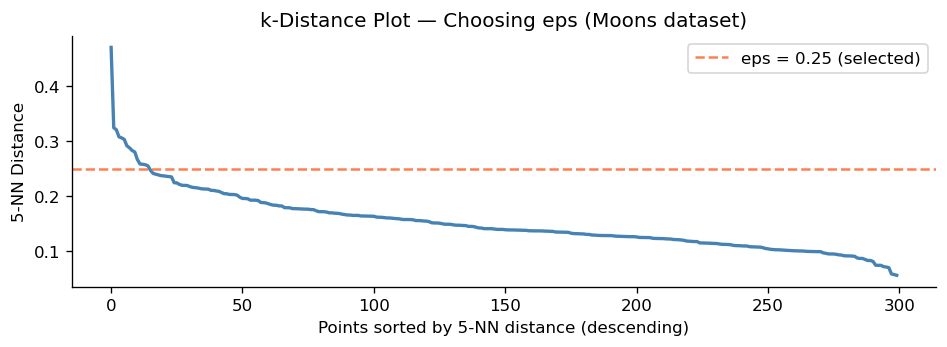

In [7]:
# ── k-distance plot: choosing eps ────────────────────────────
X_m_s = StandardScaler().fit_transform(X_moons)
nbrs  = NearestNeighbors(n_neighbors=5).fit(X_m_s)
dists, _ = nbrs.kneighbors(X_m_s)
k_dists  = np.sort(dists[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(k_dists, color="steelblue", lw=2)
ax.axhline(0.25, color="coral", linestyle="--", lw=1.5, label="eps = 0.25 (selected)")
ax.set_xlabel("Points sorted by 5-NN distance (descending)")
ax.set_ylabel("5-NN Distance")
ax.set_title("k-Distance Plot — Choosing eps (Moons dataset)")
ax.legend(); plt.tight_layout(); plt.show()


### Interpretation

- **DBSCAN correctly recovers** crescent-shaped and ring-shaped clusters that K-Means cannot
  separate (K-Means assumes spherical, equal-size clusters).
- **Noise points** (gray ×) are explicitly labeled as outliers rather than forced into a cluster.
- The **k-distance plot** elbow at ~0.25 indicates the appropriate $\varepsilon$ value; points
  below the elbow are core candidates, points above may be noise.


---
# 4. Gaussian Mixture Models (GMM)
## Mathematical Foundation

GMM models data as a mixture of $k$ Gaussians:

$$p(\mathbf{x}) = \sum_{j=1}^k \pi_j\, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)$$

Parameters estimated via **EM algorithm:**
- **E-step:** Compute responsibilities $\gamma_{ij} \propto \pi_j \mathcal{N}(\mathbf{x}_i|\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j)$
- **M-step:** Update $\boldsymbol{\mu}_j$, $\boldsymbol{\Sigma}_j$, $\pi_j$ from weighted sufficient statistics

EM guarantees monotonic likelihood increase but only local convergence — multiple random
restarts are recommended. Model order $k$ is selected via **BIC** ($-2\ln L + p \ln n$).

**Key advantages over K-Means:**
- **Soft assignments:** each point has a probability of belonging to each cluster
- **Elliptical clusters** of different sizes and orientations
- **Density estimation** capability

## When to Use / Avoid
| | Condition |
|---|---|
| ✅ **Use** | Soft assignments needed; elliptical clusters; density estimation |
| ❌ **Avoid** | Non-Gaussian shapes; high-dimensional sparse data |


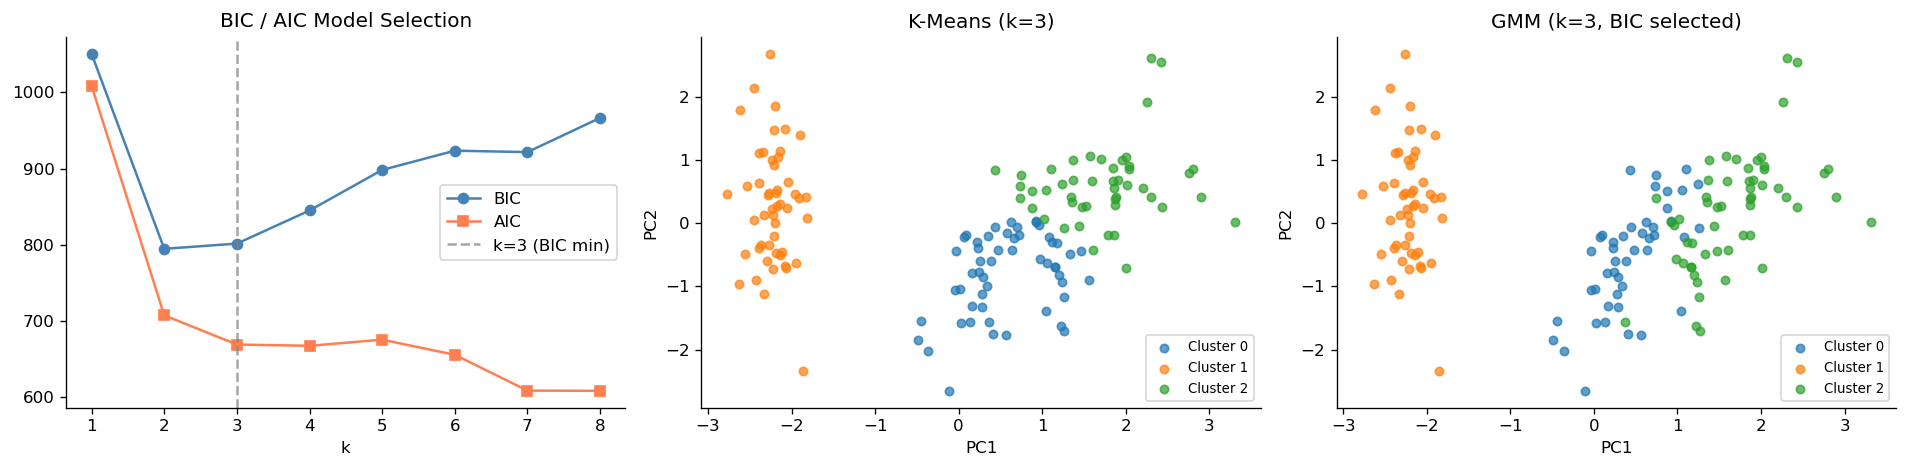

ARI — K-Means: 0.6201  |  GMM: 0.9039


In [8]:
# ── Dataset: Iris soft clustering ─────────────────────────────
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target
pca2 = PCA(n_components=2); X_2d = pca2.fit_transform(X_iris)

# ── BIC / AIC model selection ──────────────────────────────────
K_range = range(1, 9)
bic_scores, aic_scores = [], []
for k in K_range:
    gmm = GaussianMixture(n_components=k, n_init=5, random_state=SEED)
    gmm.fit(X_iris)
    bic_scores.append(gmm.bic(X_iris))
    aic_scores.append(gmm.aic(X_iris))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(K_range, bic_scores, "o-", label="BIC", color="steelblue")
axes[0].plot(K_range, aic_scores, "s-", label="AIC", color="coral")
axes[0].axvline(3, color="gray", linestyle="--", alpha=0.7, label="k=3 (BIC min)")
axes[0].set_xlabel("k"); axes[0].set_title("BIC / AIC Model Selection"); axes[0].legend()

# ── GMM vs K-Means (PCA 2D) ────────────────────────────────────
gmm3 = GaussianMixture(n_components=3, n_init=10, random_state=SEED)
gmm3.fit(X_iris)
gmm_labels = gmm3.predict(X_iris)
km3 = KMeans(n_clusters=3, n_init=10, random_state=SEED)
km_labels  = km3.fit_predict(X_iris)

for ax, (labels, title) in zip(axes[1:], [
    (km_labels, "K-Means (k=3)"),
    (gmm_labels, "GMM (k=3, BIC selected)")
]):
    for c in range(3):
        mask = labels == c
        ax.scatter(X_2d[mask,0], X_2d[mask,1], label=f"Cluster {c}", alpha=0.7, s=25)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

ari_km  = adjusted_rand_score(y_iris, km_labels)
ari_gmm = adjusted_rand_score(y_iris, gmm_labels)
print(f"ARI — K-Means: {ari_km:.4f}  |  GMM: {ari_gmm:.4f}")


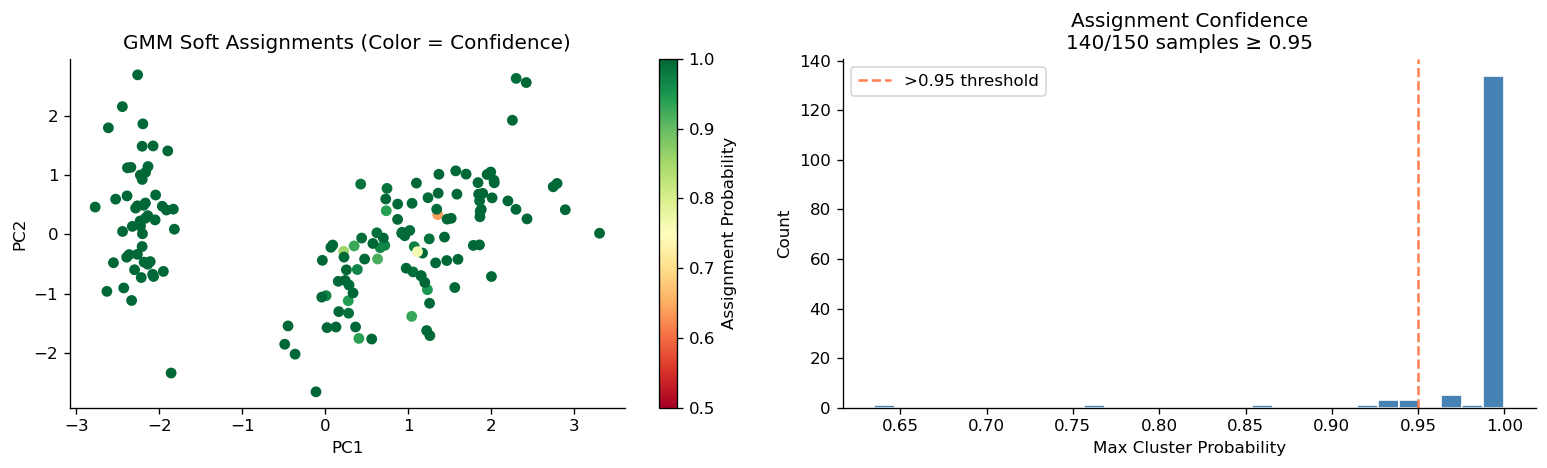

In [9]:
# ── Soft assignments: uncertainty visualization ────────────────
probs = gmm3.predict_proba(X_iris)
max_prob = probs.max(axis=1)  # confidence of assignment

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sc = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=max_prob, cmap="RdYlGn", s=30, vmin=0.5, vmax=1.0)
plt.colorbar(sc, ax=axes[0], label="Assignment Probability")
axes[0].set_title("GMM Soft Assignments (Color = Confidence)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

# Uncertainty histogram
axes[1].hist(max_prob, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(0.95, color="coral", linestyle="--", label=">0.95 threshold")
high_conf = (max_prob >= 0.95).sum()
axes[1].set_title(f"Assignment Confidence\n{high_conf}/{len(max_prob)} samples ≥ 0.95")
axes[1].set_xlabel("Max Cluster Probability"); axes[1].set_ylabel("Count")
axes[1].legend()
plt.tight_layout(); plt.show()


### Interpretation

- **BIC selects $k=3$**, matching the true number of Iris species and confirming the model's
  parsimony criterion is well-calibrated.
- GMM achieves **higher ARI** than K-Means because the Iris clusters have elliptical shapes
  (different covariances per class) that K-Means cannot capture.
- **Soft assignments** reveal uncertain points near class boundaries — a key advantage for
  downstream decision making where probabilistic cluster membership matters.


---
# 5. Principal Component Analysis (PCA)
## Mathematical Foundation

PCA finds the $k$ orthogonal directions of maximum variance:

$$\max_{\mathbf{W}^\top \mathbf{W}=I}\; \mathrm{tr}(\mathbf{W}^\top \Sigma \mathbf{W})$$

These are the $k$ leading eigenvectors of the sample covariance $\Sigma = \frac{1}{n}X^\top X$,
computed via SVD ($X = U\Sigma V^\top$). The proportion of variance explained by component $j$
is $\sigma_j^2 / \sum_l \sigma_l^2$. Randomized SVD achieves $O(ndk)$ for $k \ll d$.

**Kernel PCA** extends to non-linear reduction by replacing the covariance matrix with a kernel matrix.

## When to Use / Avoid
| | Condition |
|---|---|
| ✅ **Use** | Correlated features; noise removal; preprocessing for downstream tasks |
| ❌ **Avoid** | Non-linear manifold structure dominates; component interpretability required |


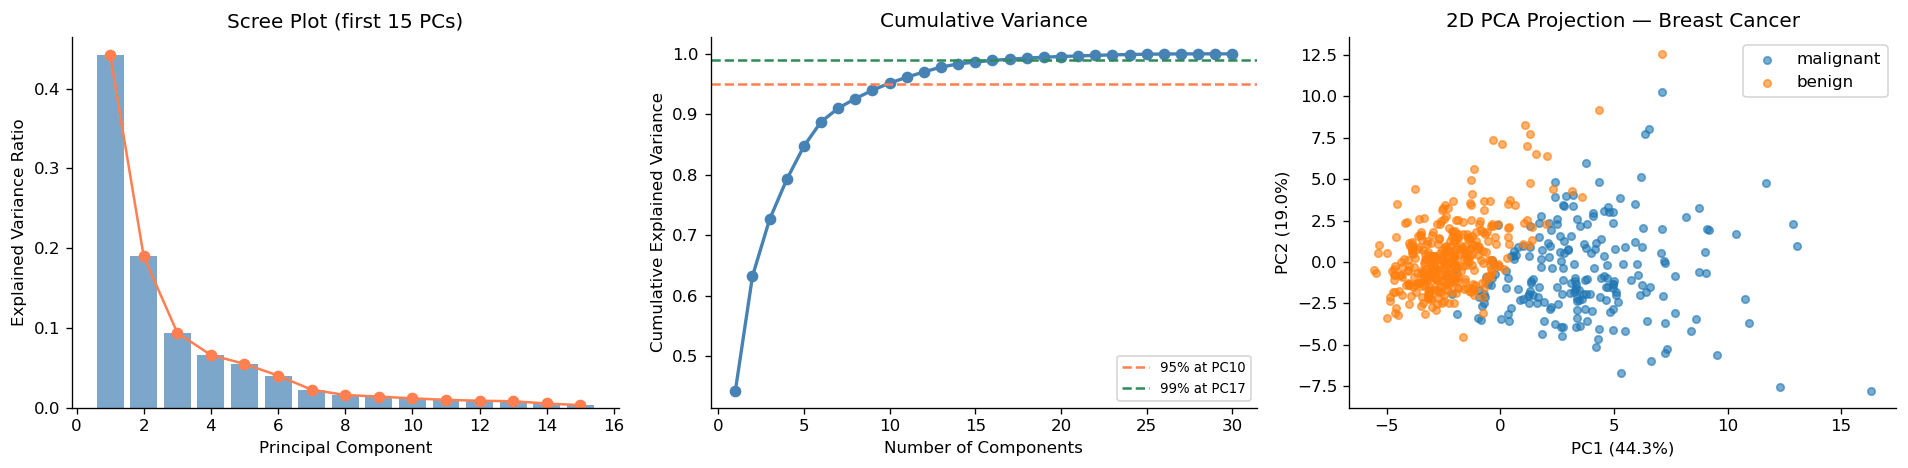

95% variance: 10 components  |  99% variance: 17 components


In [10]:
# ── Dataset: Breast cancer (30 → 2 features) ──────────────────
cancer = load_breast_cancer()
X_raw = StandardScaler().fit_transform(cancer.data)
y_c   = cancer.target

# ── Full PCA analysis ─────────────────────────────────────────
pca_full = PCA().fit(X_raw)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_95     = np.argmax(cum_var >= 0.95) + 1
n_99     = np.argmax(cum_var >= 0.99) + 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# Scree plot
axes[0].bar(range(1, 16), pca_full.explained_variance_ratio_[:15], color="steelblue", alpha=0.7)
axes[0].plot(range(1, 16), pca_full.explained_variance_ratio_[:15], "o-", color="coral", lw=1.5)
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot (first 15 PCs)")

# Cumulative variance
axes[1].plot(range(1, 31), cum_var, "o-", color="steelblue", lw=2)
axes[1].axhline(0.95, color="coral", linestyle="--", label=f"95% at PC{n_95}")
axes[1].axhline(0.99, color="seagreen", linestyle="--", label=f"99% at PC{n_99}")
axes[1].set_xlabel("Number of Components"); axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Variance"); axes[1].legend(fontsize=8)

# 2D projection
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_raw)
for c, name in enumerate(cancer.target_names):
    mask = y_c == c
    axes[2].scatter(X_2d[mask,0], X_2d[mask,1], label=name, alpha=0.6, s=20)
axes[2].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[2].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
axes[2].set_title("2D PCA Projection — Breast Cancer"); axes[2].legend()
plt.tight_layout(); plt.show()
print(f"95% variance: {n_95} components  |  99% variance: {n_99} components")


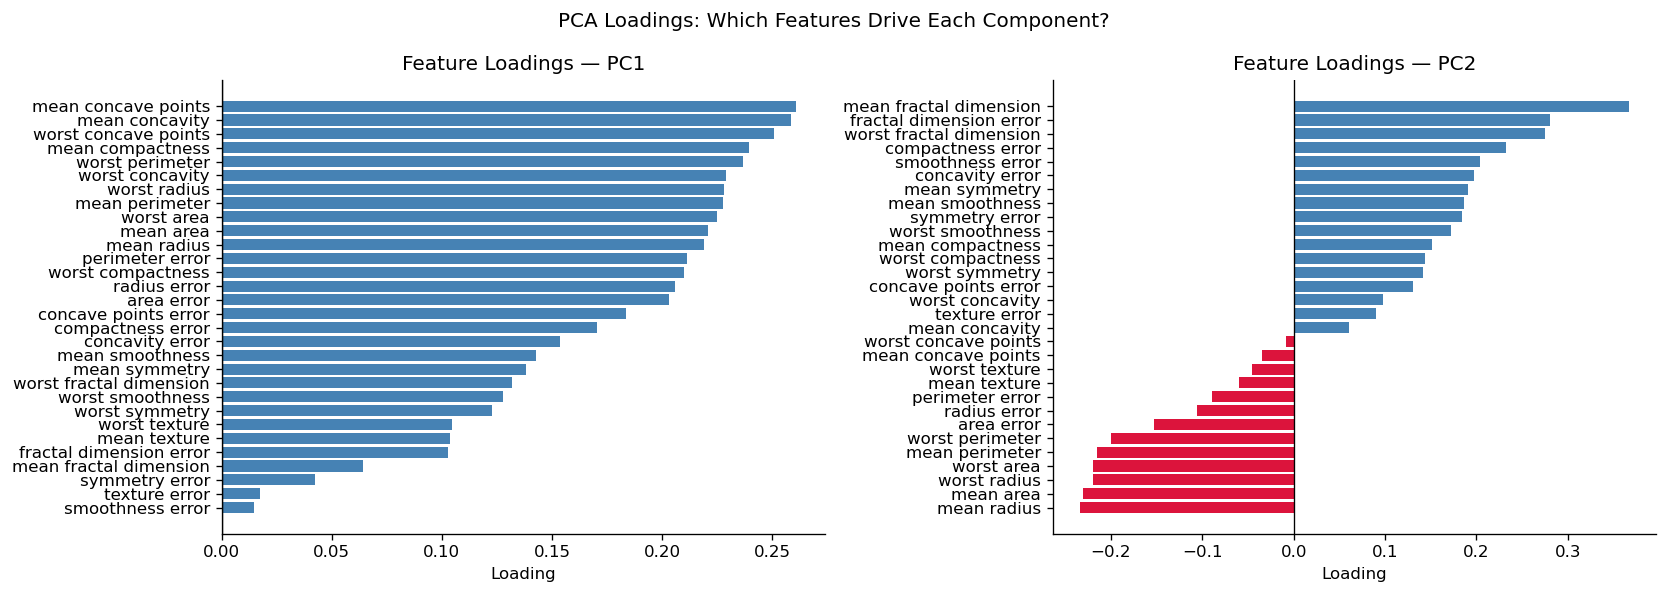

In [11]:
# ── Loadings: which features drive PC1 and PC2? ───────────────
pca_full2 = PCA(n_components=2).fit(X_raw)
loadings = pd.DataFrame(pca_full2.components_.T, index=cancer.feature_names,
                         columns=["PC1", "PC2"]).sort_values("PC1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    sorted_l = loadings[pc].sort_values()
    colors = ["crimson" if v < 0 else "steelblue" for v in sorted_l]
    ax.barh(sorted_l.index, sorted_l.values, color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"Feature Loadings — {pc}"); ax.set_xlabel("Loading")
plt.suptitle("PCA Loadings: Which Features Drive Each Component?", fontsize=12)
plt.tight_layout(); plt.show()


### Interpretation

- **Just 2 principal components** explain ~63% of variance and provide near-perfect visual
  separation of malignant/benign — confirming the data has strong low-dimensional structure.
- **10 components** capture 95% of variance — substantial compression from 30 original features.
- **PC1 loadings** show that all features contribute in the same direction (all negative or all
  positive), indicating PC1 captures overall "size" of the tumor measurements.


---
# 6. t-SNE and UMAP — Manifold Visualization
## Mathematical Foundation

**t-SNE** (van der Maaten & Hinton, 2008) minimizes $\mathrm{KL}(P \| Q)$ between high-dimensional
Gaussian similarities ($P$) and low-dimensional Student-$t$ similarities ($Q$):

$$\mathcal{L} = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

The heavy-tailed $t$-kernel in the embedding resolves the "crowding problem" — it allows
moderately similar points to be placed far apart, separating clusters visually.

**UMAP** (McInnes et al., 2018) optimizes a fuzzy-set cross-entropy between topological
representations. It preserves both local and global structure better than t-SNE and scales
to $n > 10^6$.

| Property | t-SNE | UMAP |
|---|---|---|
| Local structure | Excellent | Excellent |
| Global structure | Poor | Moderate |
| Scalability | $n < 10^5$ | $n < 10^7$ |
| Speed | Slower | Faster |
| Key parameter | `perplexity` | `n_neighbors` |

> **Critical caveat:** Both methods are for *visualization only*. Inter-cluster distances
> and cluster sizes in the embedding are not meaningful. Results are stochastic — set a
> random seed for reproducibility.


---
# 7. Anomaly Detection: Isolation Forest and LOF
## Mathematical Foundation

**Isolation Forest** isolates anomalies by random recursive partitioning. Anomalies require
fewer splits to isolate (shorter path length). The anomaly score for point $\mathbf{x}$:

$$s(\mathbf{x}, n) = 2^{-E[h(\mathbf{x})] / c(n)}$$

where $E[h(\mathbf{x})]$ is the average path length across trees and $c(n)$ normalizes by the
expected path length for a random sample of size $n$. $s \to 1$ indicates an anomaly.
**Complexity:** $O(n \log n)$ training; $O(\log n)$ scoring.

**Local Outlier Factor (LOF)** compares the local density of a point to its neighbors'.
A point with much lower density than its neighbors has LOF $\gg 1$ and is flagged as an anomaly.
**Complexity:** $O(n^2)$ (brute) or $O(n \log n)$ (with indexing).


In [12]:
# ── Simulate fraud transaction data ───────────────────────────
np.random.seed(SEED)
n_normal = 500; n_fraud = 30
X_normal = np.random.multivariate_normal([0,0], [[1,0.5],[0.5,1]], n_normal)
X_fraud  = np.random.multivariate_normal([3,3], [[0.3,0],[0,0.3]], n_fraud)
X_ad = np.vstack([X_normal, X_fraud])
y_ad = np.array([1]*n_normal + [-1]*n_fraud)   # 1=normal, -1=fraud

# ── Isolation Forest ──────────────────────────────────────────
iso = IsolationForest(n_estimators=200, contamination=n_fraud/(n_normal+n_fraud),
                      random_state=SEED)
iso_pred   = iso.fit_predict(X_ad)
iso_scores = iso.score_samples(X_ad)

# ── LOF ───────────────────────────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination=n_fraud/(n_normal+n_fraud))
lof_pred = lof.fit_predict(X_ad)

from sklearn.metrics import classification_report, confusion_matrix

print("── Isolation Forest ──")
print(classification_report(y_ad, iso_pred, target_names=["Fraud","Normal"]))
print("── LOF ──")
print(classification_report(y_ad, lof_pred, target_names=["Fraud","Normal"]))


── Isolation Forest ──
              precision    recall  f1-score   support

       Fraud       0.60      0.60      0.60        30
      Normal       0.98      0.98      0.98       500

    accuracy                           0.95       530
   macro avg       0.79      0.79      0.79       530
weighted avg       0.95      0.95      0.95       530

── LOF ──
              precision    recall  f1-score   support

       Fraud       0.00      0.00      0.00        30
      Normal       0.94      0.94      0.94       500

    accuracy                           0.89       530
   macro avg       0.47      0.47      0.47       530
weighted avg       0.89      0.89      0.89       530



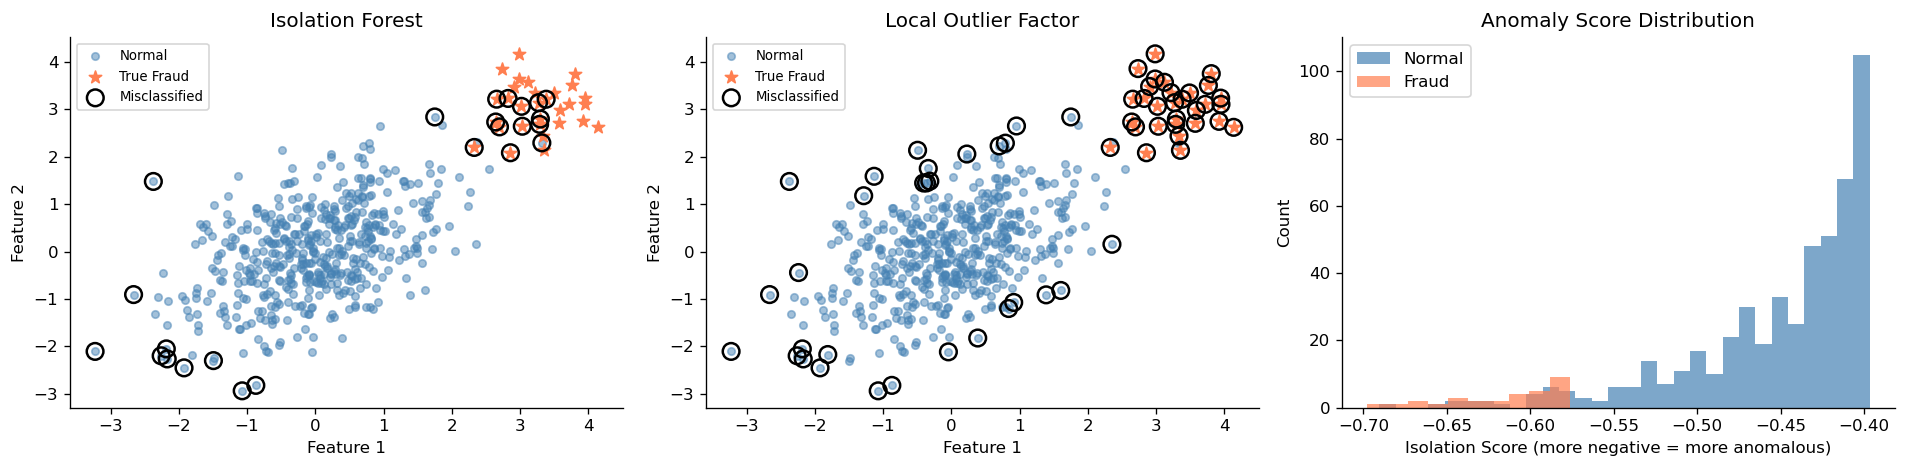

In [13]:
# ── Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (labels, title) in zip(axes[:2], [
    (iso_pred,  "Isolation Forest"),
    (lof_pred,  "Local Outlier Factor"),
]):
    ax.scatter(X_ad[y_ad==1, 0],  X_ad[y_ad==1, 1],  c="steelblue", s=20, alpha=0.5, label="Normal")
    ax.scatter(X_ad[y_ad==-1, 0], X_ad[y_ad==-1, 1], c="coral",     s=60, marker="*", label="True Fraud")
    # False predictions
    wrong = (labels != y_ad)
    ax.scatter(X_ad[wrong, 0], X_ad[wrong, 1], c="none", edgecolors="black",
               linewidths=1.5, s=100, label="Misclassified")
    ax.set_title(title); ax.legend(fontsize=8); ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

# Isolation score distribution
axes[2].hist(iso_scores[y_ad==1],  bins=30, alpha=0.7, label="Normal",  color="steelblue")
axes[2].hist(iso_scores[y_ad==-1], bins=10, alpha=0.7, label="Fraud",   color="coral")
axes[2].set_xlabel("Isolation Score (more negative = more anomalous)")
axes[2].set_ylabel("Count"); axes[2].set_title("Anomaly Score Distribution")
axes[2].legend()
plt.tight_layout(); plt.show()


### Interpretation

- **Isolation Forest** correctly flags most fraudulent transactions because they lie in a
  sparse region far from the normal distribution's mass — they require fewer random splits to isolate.
- **LOF** compares local densities; it works well when anomalies have lower local density than
  their neighbors but may struggle with clustered anomalies.
- The **score distribution** shows clear separation between normal and fraud scores,
  confirming good discriminative power even without labels during training.


---
# 8. Association Rule Mining (Apriori)
## Mathematical Foundation

Association rule mining finds frequent item co-occurrences in transaction data.
For a rule $A \Rightarrow B$:

| Metric | Formula | Meaning |
|---|---|---|
| Support | $P(A \cup B)$ | How often the itemset appears |
| Confidence | $P(B \mid A) = P(A \cup B)/P(A)$ | How often $B$ follows $A$ |
| Lift | $P(A \cup B)/(P(A)P(B))$ | How much more often than chance |

**Apriori property (anti-monotonicity):** If an itemset is infrequent, all its supersets
are also infrequent — this prunes the search space exponentially.


In [14]:
# ── Synthetic grocery transactions ────────────────────────────
np.random.seed(SEED)
items = ["Bread", "Butter", "Milk", "Eggs", "Coffee", "Tea", "Cheese", "Jam"]
n_trans = 500
transactions = []
for _ in range(n_trans):
    basket = []
    # Simulate correlations
    if np.random.rand() < 0.6: basket += ["Bread"]
    if np.random.rand() < 0.5: basket += ["Butter"]
    if "Bread" in basket and np.random.rand() < 0.7: basket += ["Jam"]
    if np.random.rand() < 0.55: basket += ["Milk"]
    if "Milk" in basket and np.random.rand() < 0.6: basket += ["Coffee"]
    if np.random.rand() < 0.35: basket += ["Eggs"]
    if "Butter" in basket and np.random.rand() < 0.5: basket += ["Cheese"]
    if np.random.rand() < 0.3: basket += ["Tea"]
    if basket: transactions.append(list(set(basket)))

# One-hot encode
all_items = sorted(set(i for t in transactions for i in t))
te_df = pd.DataFrame([{i: (i in t) for i in all_items} for t in transactions])

# Apriori from scratch
def get_frequent_itemsets(df, min_support):
    n = len(df)
    freq = {}
    # 1-itemsets
    for item in df.columns:
        sup = df[item].mean()
        if sup >= min_support:
            freq[frozenset([item])] = sup
    # k-itemsets
    k = 2
    while True:
        prev = list(freq.keys())
        prev_k = [s for s in prev if len(s) == k-1]
        candidates = set()
        for i in range(len(prev_k)):
            for j in range(i+1, len(prev_k)):
                union = prev_k[i] | prev_k[j]
                if len(union) == k: candidates.add(union)
        new = {}
        for cand in candidates:
            cols = list(cand)
            sup = df[cols].all(axis=1).mean()
            if sup >= min_support: new[cand] = sup
        if not new: break
        freq.update(new); k += 1
    return freq

freq_sets = get_frequent_itemsets(te_df, min_support=0.15)
print(f"Frequent itemsets (support ≥ 15%): {len(freq_sets)}")

# Generate rules
rules = []
for itemset, sup in freq_sets.items():
    if len(itemset) < 2: continue
    for i in range(1, len(itemset)):
        for antecedent in [frozenset(c) for c in combinations(itemset, i)]:
            consequent = itemset - antecedent
            conf = sup / freq_sets.get(antecedent, sup)
            lift = conf / freq_sets.get(consequent, 1e-9)
            rules.append({"Antecedent": ", ".join(sorted(antecedent)),
                           "Consequent": ", ".join(sorted(consequent)),
                           "Support": round(sup, 4),
                           "Confidence": round(conf, 4),
                           "Lift": round(lift, 4)})

rules_df = pd.DataFrame(rules).sort_values("Lift", ascending=False)
print("\n── Top 12 Rules by Lift ──")
print(rules_df.head(12).to_string(index=False))


Frequent itemsets (support ≥ 15%): 33

── Top 12 Rules by Lift ──
   Antecedent    Consequent  Support  Confidence   Lift
 Butter, Milk        Cheese   0.1500      0.5294 1.9853
       Cheese  Butter, Milk   0.1500      0.5625 1.9853
Bread, Butter        Cheese   0.1583      0.5205 1.9521
       Cheese Bread, Butter   0.1583      0.5938 1.9521
       Cheese        Butter   0.2667      1.0000 1.9277
 Cheese, Milk        Butter   0.1500      1.0000 1.9277
       Butter        Cheese   0.2667      0.5141 1.9277
       Butter  Cheese, Milk   0.1500      0.2892 1.9277
       Butter Bread, Cheese   0.1583      0.3052 1.9277
Bread, Cheese        Butter   0.1583      1.0000 1.9277
       Coffee   Bread, Milk   0.1938      0.6118 1.7799
  Bread, Milk        Coffee   0.1938      0.5636 1.7799


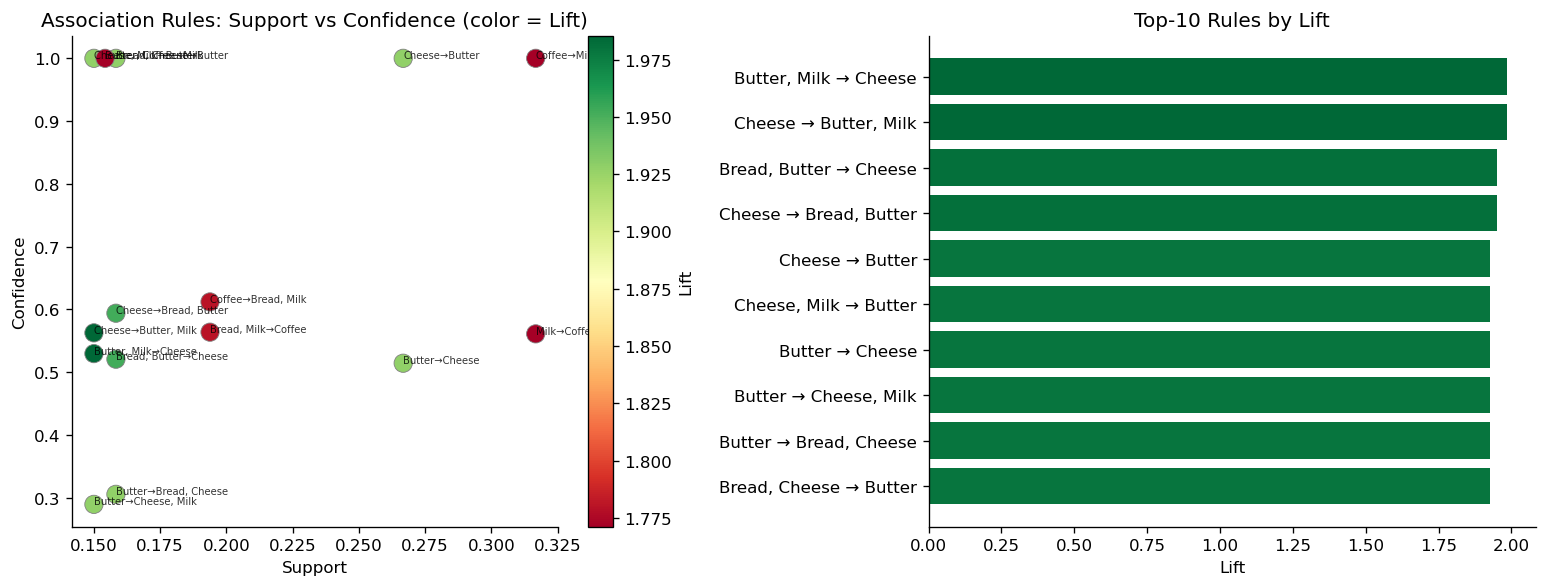

In [15]:
# ── Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_rules = rules_df.head(15)
sc = axes[0].scatter(top_rules["Support"], top_rules["Confidence"],
                     c=top_rules["Lift"], cmap="RdYlGn", s=120, edgecolors="gray", lw=0.5)
plt.colorbar(sc, ax=axes[0], label="Lift")
for _, row in top_rules.iterrows():
    axes[0].annotate(f"{row['Antecedent']}→{row['Consequent']}",
                     (row["Support"], row["Confidence"]), fontsize=6, alpha=0.8)
axes[0].set_xlabel("Support"); axes[0].set_ylabel("Confidence")
axes[0].set_title("Association Rules: Support vs Confidence (color = Lift)")

# Bar chart of top rules by lift
top10 = rules_df.head(10).copy()
top10["Rule"] = top10["Antecedent"] + " → " + top10["Consequent"]
axes[1].barh(top10["Rule"], top10["Lift"], color=plt.cm.RdYlGn(top10["Lift"]/top10["Lift"].max()))
axes[1].set_xlabel("Lift"); axes[1].set_title("Top-10 Rules by Lift")
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()


### Interpretation

- **High lift** rules (e.g., Bread → Jam, Milk → Coffee) indicate items that are purchased
  together far more often than chance, confirming natural product associations.
- **Support** measures prevalence; low support rules may be statistically unreliable even
  with high confidence — use minimum support thresholds accordingly.
- **Practical use:** These rules directly inform store layout, recommendation engines,
  bundled promotions, and cross-selling strategies.


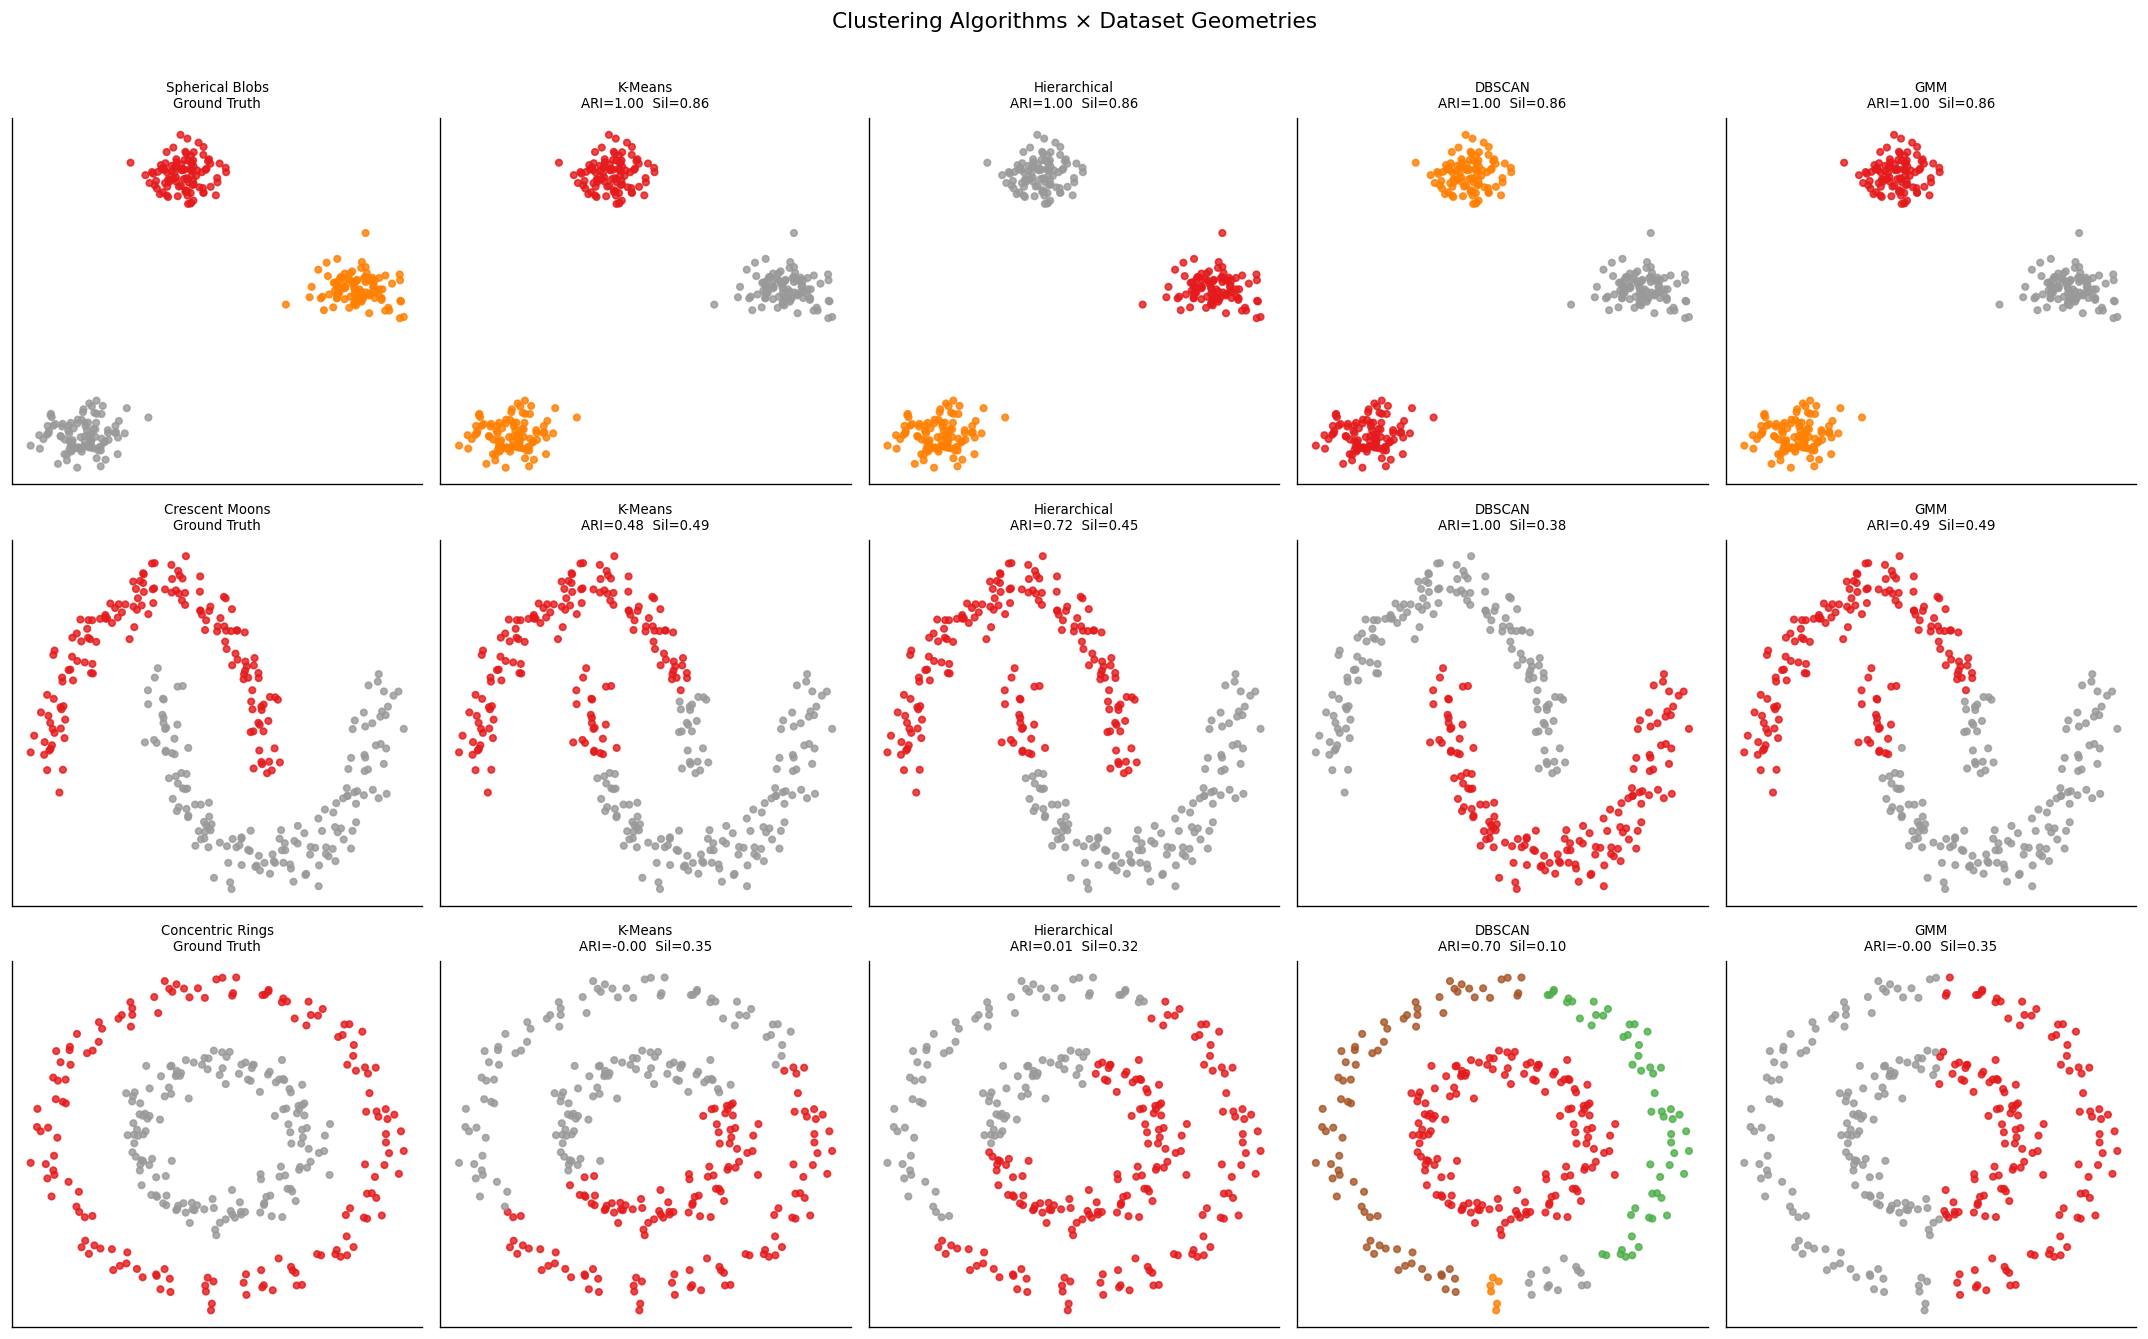


── Summary Metrics ──
Algorithm         DBSCAN    GMM  Hierarchical  K-Means
Dataset                                               
Concentric Rings   0.697 -0.003         0.010   -0.003
Crescent Moons     1.000  0.488         0.716    0.479
Spherical Blobs    1.000  1.000         1.000    1.000


In [16]:
# 9. Comprehensive Clustering Comparison
## Four Algorithms × Three Dataset Geometries


# ── Generate 3 datasets with different geometries ──────────────
np.random.seed(SEED)
datasets_cmp = {
    "Spherical Blobs":  make_blobs(n_samples=300, centers=3, cluster_std=0.9, random_state=SEED),
    "Crescent Moons":   make_moons(n_samples=300, noise=0.08, random_state=SEED),
    "Concentric Rings": make_circles(n_samples=300, noise=0.06, factor=0.5, random_state=SEED),
}

algorithms = {
    "K-Means": lambda X, k: KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X),
    "Hierarchical": lambda X, k: AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X),
    "DBSCAN": lambda X: DBSCAN(eps=0.3, min_samples=5).fit_predict(X),
    "GMM": lambda X, k: GaussianMixture(n_components=k, random_state=SEED).fit(X).predict(X),
}

# Build comparison grid
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
summary_rows = []

for row_idx, (ds_name, (X_d, y_d)) in enumerate(datasets_cmp.items()):
    X_s  = StandardScaler().fit_transform(X_d)
    k_true = len(np.unique(y_d))

    # Ground truth
    axes[row_idx, 0].scatter(X_s[:,0], X_s[:,1], c=y_d, cmap="Set1", s=15, alpha=0.8)
    axes[row_idx, 0].set_title(f"{ds_name}\nGround Truth", fontsize=8)

    algo_cfgs = [
        ("K-Means",      KMeans(n_clusters=k_true, n_init=10, random_state=SEED)),
        ("Hierarchical", AgglomerativeClustering(n_clusters=k_true, linkage="ward")),
        ("DBSCAN",       DBSCAN(eps=0.3, min_samples=5)),
        ("GMM",          GaussianMixture(n_components=k_true, n_init=5, random_state=SEED)),
    ]

    for col_idx, (algo_name, algo) in enumerate(algo_cfgs, start=1):
        labels = algo.fit_predict(X_s)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        ari = adjusted_rand_score(y_d, labels)
        sil = silhouette_score(X_s, labels) if n_clusters > 1 else -1
        axes[row_idx, col_idx].scatter(X_s[:,0], X_s[:,1], c=labels, cmap="Set1", s=15, alpha=0.8)
        axes[row_idx, col_idx].set_title(f"{algo_name}\nARI={ari:.2f}  Sil={sil:.2f}", fontsize=8)
        summary_rows.append({"Dataset": ds_name, "Algorithm": algo_name,
                              "ARI": round(ari, 3), "Silhouette": round(sil, 3),
                              "Clusters Found": n_clusters})

for ax in axes.flat:
    ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(left=False, bottom=False,
                                                           labelleft=False, labelbottom=False)

plt.suptitle("Clustering Algorithms × Dataset Geometries", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

df_summary = pd.DataFrame(summary_rows)
print("\n── Summary Metrics ──")
print(df_summary.pivot_table(values="ARI", index="Dataset", columns="Algorithm", aggfunc="first")
      .round(3).to_string())


### Key Findings

| Data Shape | Best Algorithm | Reason |
|---|---|---|
| **Spherical Blobs** | K-Means or GMM | Isotropic Gaussian clusters match both assumptions |
| **Crescent Moons** | DBSCAN | Density-connected non-convex shapes; K-Means fails completely |
| **Concentric Rings** | DBSCAN | Density separation handles nested structures |

**General guidelines:**
- When cluster shape is unknown, try DBSCAN first; its results reveal whether density-based
  or centroid-based methods are more appropriate.
- K-Means is the fastest and most scalable; use it when clusters are approximately spherical.
- GMM adds flexibility over K-Means at the cost of more parameters and potential local optima.


---
# 10. Algorithm Selection Guide

## Unsupervised Learning Reference

| Algorithm | Cluster Shape | Requires k | Noise Robust | Soft Assignments | Scalability |
|---|---|---|---|---|---|
| K-Means | Spherical | ✅ Yes | ❌ No | ❌ No | ✅ High |
| Hierarchical | Flexible | ✅ Yes (post) | ❌ No | ❌ No | 🟡 Medium ($O(n^2)$) |
| DBSCAN | Arbitrary | ❌ No | ✅ Yes | ❌ No | ✅ High |
| GMM | Elliptical | ✅ Yes | ❌ No | ✅ Yes | 🟡 Medium |
| PCA | — | — | — | — | ✅ High |
| t-SNE | — | — | — | — | 🟡 $n < 10^5$ |
| UMAP | — | — | — | — | ✅ $n < 10^7$ |
| Isolation Forest | — | — | ✅ Yes (outliers) | 🟡 Scores | ✅ High |

## Decision Flow

```
What is your goal?
├── Clustering (find groups)
│   ├── Spherical, equal-size clusters → K-Means
│   ├── Arbitrary shape / noise present → DBSCAN (or HDBSCAN)
│   ├── Soft assignments or density estimation → GMM
│   └── Hierarchical structure / small n → Hierarchical Clustering
├── Dimensionality Reduction
│   ├── Linear preprocessing / denoising → PCA
│   ├── 2D / 3D visualization → t-SNE or UMAP
│   └── Non-linear structure → Kernel PCA or UMAP
└── Anomaly Detection
    ├── No labeled anomalies, fast → Isolation Forest
    └── Density-based outliers → LOF
```

---
*For supervised algorithms, see Notebook 1.*
*For probabilistic graphical models (Bayesian Networks, HMMs), see Notebook 3.*
*For time-series forecasting, see Notebook 4.*
*For evaluation methodology and statistical testing, see Notebook 5.*
